# E41 — Quantos dias a memória devolve

A capacidade de memória de cada sistema: quantos dias individuais do passado o estado devolve por
leitura linear, medida fora da amostra.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from frevolab import dados, graficos, capacidade

SEMENTE = 108          # <- brinque com:
LAGS = 1500
FRACAO_TREINO = 0.5
SORTES = 20
MEIA_VIDA = 21
ALFA = 1.0 - 2.0 ** (-1.0 / MEIA_VIDA)

retornos = dados.carregar_serie("sp500.csv").pct_change().dropna()
print("sp %d dias | alfa da meia-vida %d: %.5f" % (retornos.size, MEIA_VIDA, ALFA))

sp 6718 dias | alfa da meia-vida 21: 0.03247


In [2]:
# Os quatro sistemas do capitulo, agora como ESTADOS.
est_acum = capacidade.estados_acumulada(retornos)
est_exp = capacidade.estados_exponencial(retornos, ALFA)
est_jan = capacidade.estados_janela(retornos, 250)
perf_acum = capacidade.capacidade_por_lag(est_acum, retornos, LAGS, FRACAO_TREINO)
perf_exp = capacidade.capacidade_por_lag(est_exp, retornos, LAGS, FRACAO_TREINO)
perf_jan = capacidade.capacidade_por_lag(est_jan, retornos, LAGS, FRACAO_TREINO)
tot_acum = capacidade.capacidade_total(perf_acum)
tot_exp = capacidade.capacidade_total(perf_exp)
tot_jan = capacidade.capacidade_total(perf_jan)
print("acumulada %.3f | exponencial %.3f | janela %.3f (contra 250)" % (tot_acum, tot_exp, tot_jan))

acumulada 0.198 | exponencial 0.822 | janela 250.686 (contra 250)


In [3]:
# O reservatorio de cem, com a incerteza ENTRE sortes.
totais, perfis = [], []
for i in range(SORTES):
    est_res = capacidade.estados_reservatorio(retornos, 100, raio=0.95, semente=SEMENTE + 1000 + i)
    perf = capacidade.capacidade_por_lag(est_res, retornos, LAGS, FRACAO_TREINO)
    perfis.append(perf)
    totais.append(capacidade.capacidade_total(perf))
ks = sorted(perfis[0])
mediana = np.array([np.median([p[k] for p in perfis if k in p]) for k in ks])
tot_res = float(np.median(totais))
tot_res_min, tot_res_max = float(np.quantile(totais, 0.025)), float(np.quantile(totais, 0.975))
abaixo = [k for i, k in enumerate(ks) if mediana[i] < mediana[0] / 2.0]
lag_metade = abaixo[0] if abaixo else ks[-1]
print("reservatorio total %.2f [%.2f; %.2f] contra n=100 | lag da metade %d | C1 %.3f" % (
    tot_res, tot_res_min, tot_res_max, lag_metade, mediana[0]))

reservatorio total 68.38 [47.32; 74.66] contra n=100 | lag da metade 68 | C1 1.000


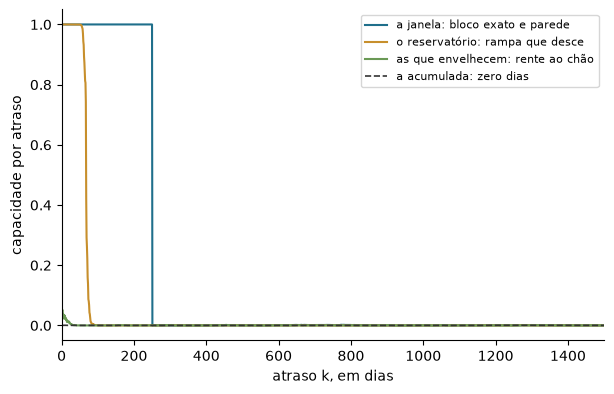

In [4]:
# Figura 1: o perfil C_k --- onde a capacidade mora.
ks_jan = sorted(perf_jan)
ks_ac = sorted(perf_acum)
ks_ex = sorted(perf_exp)
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(ks_jan, [perf_jan[k] for k in ks_jan], "-", color="#1f6f8b", lw=1.5,
        label="a janela: bloco exato e parede")
ax.plot(ks, mediana, "-", color="#c78f2c", lw=1.5, label="o reservatório: rampa que desce")
ax.plot(ks_ex, [perf_exp[k] for k in ks_ex], "-", color="#6a9955", lw=1.5,
        label="as que envelhecem: rente ao chão")
ax.plot(ks_ac, [perf_acum[k] for k in ks_ac], "--", color="#333333", lw=1.2,
        label="a acumulada: zero dias")
ax.set_xlabel("atraso k, em dias")
ax.set_ylabel("capacidade por atraso")
ax.set_xlim(0, LAGS)
ax.legend(fontsize=8, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E41_capacidade", 1)
plt.show()

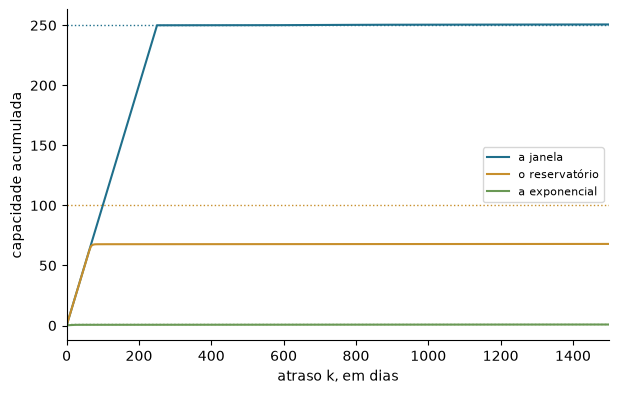

In [5]:
# Figura 2: a capacidade acumulada contra o lag, com as linhas do tamanho de cada estado.
cum_jan = np.cumsum([perf_jan[k] for k in ks_jan])
cum_res = np.cumsum(mediana)
cum_exp = np.cumsum([perf_exp[k] for k in ks_ex])
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(ks_jan, cum_jan, "-", color="#1f6f8b", lw=1.5, label="a janela")
ax.plot(ks, cum_res, "-", color="#c78f2c", lw=1.5, label="o reservatório")
ax.plot(ks_ex, cum_exp, "-", color="#6a9955", lw=1.5, label="a exponencial")
ax.axhline(250, color="#1f6f8b", ls=":", lw=1.0)
ax.axhline(100, color="#c78f2c", ls=":", lw=1.0)
ax.axhline(1.0, color="#6a9955", ls=":", lw=1.0)
ax.set_xlabel("atraso k, em dias")
ax.set_ylabel("capacidade acumulada")
ax.set_xlim(0, LAGS)
ax.legend(fontsize=8, loc="center right")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E41_capacidade", 2)
plt.show()

In [6]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) a janela fica em um ate o seu tamanho e cai a zero; o reservatorio parte alto e desce suave;
#    a exponencial e a acumulada ficam rente ao chao desde o comeco;
# 2) as acumuladas: a janela para no tamanho exato (duzentos e cinquenta); o reservatorio sobe
#    devagar e satura em dois tercos da dimensao; a exponencial e a acumulada nem saem do chao.

In [7]:
# O que sai do laboratório e o que o livro cita.
resultado = {"capacidade_acumulada_total": round(tot_acum, 3),
             "capacidade_exponencial_total": round(tot_exp, 3),
             "capacidade_janela_total": round(tot_jan, 3),
             "capacidade_reservatorio_total": round(tot_res, 2),
             "capacidade_reservatorio_total_min": round(tot_res_min, 2),
             "capacidade_reservatorio_total_max": round(tot_res_max, 2),
             "capacidade_reservatorio_lag_metade": int(lag_metade),
             "capacidade_reservatorio_primeiro": round(float(mediana[0]), 3)}

import json
from pathlib import Path
caminho = Path("lab/resultados/E41_capacidade.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "capacidade_acumulada_total": 0.198,
 "capacidade_exponencial_total": 0.822,
 "capacidade_janela_total": 250.686,
 "capacidade_reservatorio_lag_metade": 68,
 "capacidade_reservatorio_primeiro": 1.0,
 "capacidade_reservatorio_total": 68.38,
 "capacidade_reservatorio_total_max": 74.66,
 "capacidade_reservatorio_total_min": 47.32
}
